In [1]:
import gurobipy as gp
from gurobipy import GRB
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
import sys
import os

# Add the directory containing m_degree.py to sys.path
module_path = os.path.abspath("../../src/b_chromatic")
if module_path not in sys.path:
    sys.path.append(module_path)

from m_degree import get_total_m_degree, get_m_degree

In [3]:
print("Gurobi version:", gp.gurobi.version())
print("NetworkX version:", nx.__version__)

Gurobi version: (12, 0, 2)
NetworkX version: 3.4.2


In [22]:
def total_graph(G):
    """
    Returns the total graph of the input graph G.
    The total graph has as nodes both the original nodes and edges of G.
    Edges are added between:
      - adjacent nodes,
      - incident node-edge pairs,
      - adjacent edges (edges sharing a node).
    """
    TG = nx.Graph()
    # new naming convention for vertices in TG that are vertices in G
    # vertex u in G is represented as (u, u) in TG
    new_nodes = {u:(u, u) for u in G.nodes()}
    # Add original nodes and edges as nodes in TG
    TG.add_nodes_from(new_nodes.values())

    # Add edges between original nodes but with new naming convention
    for u, v in G.edges():
        TG.add_edge(new_nodes[u], new_nodes[v])
    # Add edges between nodes and incident edges
    for u, v in G.edges():
        TG.add_edge(new_nodes[u], (u, v))
        TG.add_edge(new_nodes[v], (u, v))
    # Add edges between adjacent edges (edges sharing a node)
    for u,v in G.edges():
        for u1 in G.adj[u]:
            if u1 != v:
                if u1 < u: TG.add_edge((u, v), (u1, u))
                else: TG.add_edge((u, v), (u, u1))
        for v1 in G.adj[v]:
            if v1 != u:
                if v1 < v: TG.add_edge((u, v), (v1, v))
                else: TG.add_edge((u, v), (v, v1))
    return TG

In [23]:
G = nx.random_graphs.erdos_renyi_graph(10, 0.5)
TG = total_graph(G)

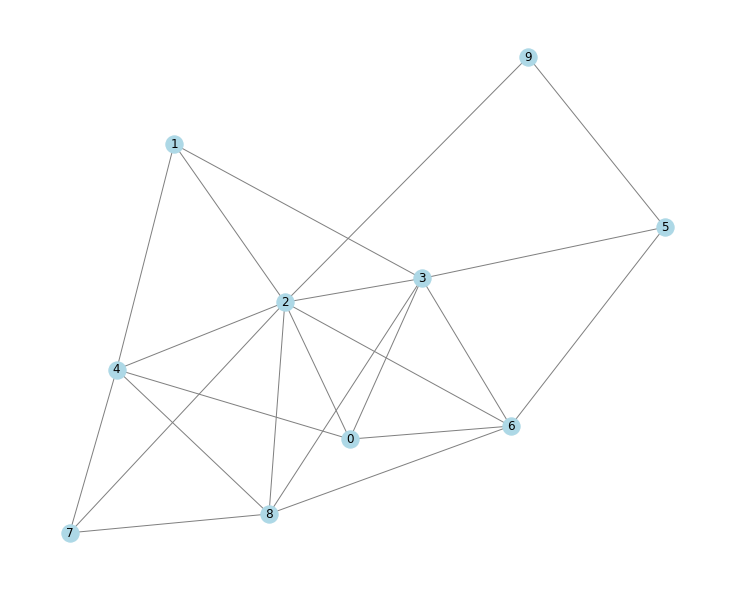

In [24]:
plt.figure(figsize=(10, 8))
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray')
plt.show()

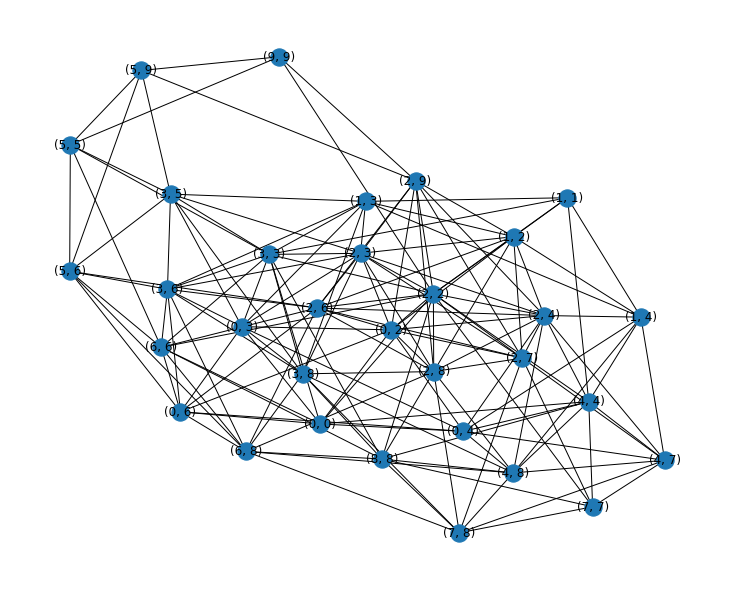

In [25]:
plt.figure(figsize=(10, 8))
nx.draw(TG, with_labels=True)
plt.show()

In [27]:
for u,v in G.edges():
    try:
        assert 2*G.degree(u) == TG.degree((u,u))
        assert 2*G.degree(v) == TG.degree((v,v))
        assert G.degree(u)+ G.degree(v) == TG.degree((u,v))
    except AssertionError:
        print(f"Assertion failed for edge ({u}, {v})")
        print(f"2*d({u}) = {2*G.degree(u)}, dt({u}) = {TG.degree((u,u))}")
        print(f"2*d({v}) = {2*G.degree(v)}, dt({v}) = {TG.degree((v,v))}")
        print(f"d({u})+d({v}) = {G.degree((u,u))+G.degree((v,v))}, dt(({u}, {v})) = {TG.degree((u, v))}")
        sys.exit(1)
print("All assertions passed.")

All assertions passed.


In [28]:
# computing the total m-degree of G
mt = get_total_m_degree(G)
print("Total m-degree of G:", mt)
# computing the m-degree of TG
m_degree_TG = get_m_degree(TG)
print("m-degree of TG:", m_degree_TG)
assert mt == m_degree_TG, "Total m-degree of G does not match m-degree of TG"

Total m-degree of G: 11
m-degree of TG: 11


Partitioning $T(G)$ into cliques

In [29]:
def get_cliques(G):
    """
    Returns a list of cliques in the total graph of G. Every clique is given by a vertex.
    A clique is a complete subgraph where every pair of nodes is connected.
    """
    # cliques for every vertex in G
    cliques = {u:[(u,u)] for u in G.nodes()}
    for u in cliques:
        for v in G.adj[u]:
            if u < v:
                cliques[u].append((u,v))
            else:
                cliques[u].append((v,u))
        print(f"Clique for vertex {u}: {cliques[u]}")
    return cliques

The cliques
- $K_i$: the set of vertices in the $i$-th clique of the graph $G$.
- $V(T(G))$: the set of vertices in the tree $T(G)$.
- $C$: the set of colors.

The variables
- $x_{vc}$: binary variable indicating if vertex $v$ is assigned to color $c$.
- $z_{vc}$: binary variable indicating if vertex $v$ is a b-chromatic vertex for color $c$.
- $d_c$: binary variable indicating if there exists a b-chromatic vertex for color $c$.

The ILP model
$$\begin{align*}
\text{maximize} \quad & \sum_{c\in C}d_c \\
\text{subject to} \quad & \sum_{c\in C}x_{vc} = 1 & \forall v\in V(T(G)) \\
                        & \sum_{v\in K_i}x_{vc} \leq 1 & \forall i=1,\dots, n, \forall c\in C \\
                        & x_{uc}+x_{vc} \leq 1 & \forall u,v\in E(G), \forall c\in C,\\
                        & z_{vc}\leq \sum_{w\in N(v)}x_{wd} & \forall v\in V(T(G)), \forall c,d\in C, c\neq d \\
                        & d_c\leq \sum_{v\in V}z_{vc} & \forall c\in C \\
                        & d_c, z_{vc}, x_{vc} \in \{0,1\} & \forall v\in V(T(G)), \forall c\in C \\
\end{align*}$$

In [30]:
# Set of colours
C = [i for i in range(1, m_degree_TG + 1)]

# Set of cliques in TG covering edges not in G
cliques = get_cliques(G)

Clique for vertex 0: [(0, 0), (0, 2), (0, 3), (0, 4), (0, 6)]
Clique for vertex 1: [(1, 1), (1, 2), (1, 3), (1, 4)]
Clique for vertex 2: [(2, 2), (0, 2), (1, 2), (2, 3), (2, 4), (2, 6), (2, 7), (2, 8), (2, 9)]
Clique for vertex 3: [(3, 3), (0, 3), (1, 3), (2, 3), (3, 5), (3, 6), (3, 8)]
Clique for vertex 4: [(4, 4), (0, 4), (1, 4), (2, 4), (4, 7), (4, 8)]
Clique for vertex 5: [(5, 5), (3, 5), (5, 6), (5, 9)]
Clique for vertex 6: [(6, 6), (0, 6), (2, 6), (3, 6), (5, 6), (6, 8)]
Clique for vertex 7: [(7, 7), (2, 7), (4, 7), (7, 8)]
Clique for vertex 8: [(8, 8), (2, 8), (3, 8), (4, 8), (6, 8), (7, 8)]
Clique for vertex 9: [(9, 9), (2, 9), (5, 9)]


In [126]:
# Variables of the model
model = gp.Model("TotalGraphb-chromaticColouringCliques")
x = model.addVars(TG.nodes(), C, vtype=GRB.BINARY, name="x")
z = model.addVars(TG.nodes(), C, vtype=GRB.BINARY, name="z")
d = model.addVars(C, vtype=GRB.BINARY, name="d")

In [ ]:
# Constraints
# Each node in TG must be assigned exactly one colour
for u in TG.nodes():
    if isinstance(u, tuple):
        model.addConstr(gp.quicksum(x[(*u, c)] for c in C) == 1, name=f"Node_{u}_colouring")
    else:
        model.addConstr(gp.quicksum(x[(u, c)] for c in C) == 1, name=f"Node_{u}_colouring")

# Each clique must be assigned exactly one colour
for u, clique in cliques.items():
    for c in C:
        model.addConstr(
            gp.quicksum(x[(*v, c)] if isinstance(v, tuple) else x[(v, c)] for v in clique) <= 1,
            name=f"Clique_{u}_colouring_{c}"
        )

for u, v in G.edges():
    for c in C:
        model.addConstr(x[(u, c)] + x[(v, c)] <= 1, name=f"Edge_{u}_{v}_colouring")

# If v is a b-chromatic vertex of colour c in TG, then there must exists an element adjacent or incident to v of colour d!= c
for u in TG.nodes():
    for c in C:
        if isinstance(u, tuple):
            model.addConstr(
                gp.quicksum(
                    x[(*v, d)] if isinstance(v, tuple) else x[(v,d)] 
                    for v in TG.adj[u] for d in C if d != c
                    ) >= z[(*u, c)], 
                    name=f"Adjacency_{u}_{c}")
        else:
            model.addConstr(
                gp.quicksum(
                    x[(*v, d)] if isinstance(v, tuple) else x[(v,d)] for v in TG.adj[u] for d in C if d != c
                    ) >= z[(u, c)], 
                    name=f"Adjacency_{u}_{c}")

# There exists a b-chromatic element of colour c for each colour c
for c in C:
    model.addConstr(
        gp.quicksum(z[(*u, c)] if isinstance(u, tuple) else z[(u, c)] for u in TG.nodes()) >= d[c],
        name=f"Existence_b_chromatic_{c}"
    )

In [128]:
# Objective: maximize the number of colours used
model.setObjective(gp.quicksum(d[c] for c in C), GRB.MAXIMIZE)

In [129]:
# 1. Optimize
model.optimize()

# 2. Check solution status
if model.status == GRB.OPTIMAL:
    print("Optimal solution found!")
    # 4. Print variable values
    for v in model.getVars():
        print(f"{v.varName} = {v.x}")
    print(f"Objective value: {model.objVal}")
else:
    print("No optimal solution found. Status:", model.status)

Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 24.5.0 24F74)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 770 rows, 737 columns and 37862 nonzeros
Model fingerprint: 0x80c3eade
Variable types: 0 continuous, 737 integer (737 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective -0.0000000
Presolve removed 165 rows and 0 columns
Presolve time: 0.06s
Presolved: 605 rows, 737 columns, 37620 nonzeros
Variable types: 0 continuous, 737 integer (737 binary)

Root relaxation: objective 1.100000e+01, 121 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0      11.0000000   11.00000  

In [130]:
model.optimize()
if model.status == GRB.INFEASIBLE:
    model.computeIIS()
    for c in model.getConstrs():
        if c.IISConstr:
            print(f"Infeasible constraint: {c.ConstrName}")

Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 24.5.0 24F74)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 770 rows, 737 columns and 37862 nonzeros
Model fingerprint: 0x80c3eade
Variable types: 0 continuous, 737 integer (737 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Presolved: 605 rows, 737 columns, 37620 nonzeros

Continuing optimization...


Explored 1 nodes (121 simplex iterations) in 0.01 seconds (0.00 work units)
Thread count was 8 (of 8 available processors)

Solution count 2: 11 -0 

Optimal solution found (tolerance 1.00e-04)
Best objective 1.100000000000e+01, best bound 1.100000000000e+01, gap 0.0000%


In [4]:
# Example: create a model
model = gp.Model("example")
x = model.addVar(name="x")
y = model.addVar(name="y")
model.addConstr(x + y >= 1, "c0")
model.setObjective(x + y, GRB.MAXIMIZE)
model.optimize()
if model.status == GRB.OPTIMAL:
    print(f"x = {x.X}, y = {y.X}")
else:
    print("No optimal solution found. Status:", model.status)

Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 24.5.0 24F74)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1 rows, 2 columns and 2 nonzeros
Model fingerprint: 0x5263d70c
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve time: 0.00s

Solved in 0 iterations and 0.00 seconds (0.00 work units)
Infeasible or unbounded model
No optimal solution found. Status: 4


In [ ]:
if model.status == GRB.OPTIMAL:
    print(f"x = {x.X}, y = {y.X}")
else:
    print("No optimal solution found. Status:", model.status)